# Parameter-Space Trajectory Metrics — Batch Size Sweep

**Structure:**
1. Setup & imports
2. Pure functions (model, data, one trial) — no global state
3. Sweep configuration — **edit this cell to change what gets swept**
4. Run the 1-D sweep (batch fraction only)
5. Plots for 1-D sweep (5a–5e)
6. Grid sweep configuration (batch fraction × LR)
7. Run the grid sweep
8. Grid heatmaps (8a: 4-panel heatmap, 8b: TOPSIS ranking)
9. Observations & next directions

**To change the 1-D sweep axis:** edit Cell 3, re-run Cells 3→4→5.  
**To run the grid:** edit Cell 6, re-run Cells 6→7→8.  
Cell 2 (pure functions) never needs to change unless you change the architecture.

## 1. Setup & Imports

Imports, device selection, and MNIST download. All shared data structures are created here. The `figs/` directory is also created so plots can be saved automatically.

In [69]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('figs', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Download MNIST once up front
_transform = transforms.Compose([transforms.ToTensor()])
_mnist_train = datasets.MNIST('.', train=True,  download=True, transform=_transform)
_mnist_test  = datasets.MNIST('.', train=False, download=True, transform=_transform)
DATASET_SIZE = len(_mnist_train)  # 60000
_test_loader = torch.utils.data.DataLoader(_mnist_test, batch_size=1000, shuffle=False)
print(f'Dataset size: {DATASET_SIZE}')

Using device: cpu
Dataset size: 60000


## 2. Pure Functions

Stateless, side-effect-free building blocks. No global writes — safe to re-run without resetting other cells.

| Function | Purpose |
|---|---|
| `make_loader` | Fresh shuffled DataLoader for a given batch size |
| `make_model` | Randomly-initialised 784 → 128 → ReLU → 10 network |
| `snapshot_params` | Clone all parameter tensors for delta computation |
| `accumulate_deltas` | Per-step accumulation of gross path **G** and net displacement **D** |
| `compute_network_efficiencies` | Scalar η1 and η2 from accumulated G/D dicts |
| `compute_per_param_efficiency` | Per-scalar-parameter η_i flat tensor |
| `evaluate_test` | Test-set accuracy and CE loss |
| `run_trial` | Full training run returning step histories and final metrics |

In [70]:
def make_loader(batch_size: int):
    """Fresh shuffled loader for a given batch size."""
    return torch.utils.data.DataLoader(
        _mnist_train,
        batch_size=batch_size,
        shuffle=True
    )


def make_model() -> nn.Module:
    """Fresh randomly-initialised model. Same architecture every call."""
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    ).to(device)
    return model


def snapshot_params(model) -> dict:
    """Clone all parameter tensors for delta computation."""
    return {name: p.data.clone() for name, p in model.named_parameters()}


def accumulate_deltas(model, prev_params, G, D):
    """After optimizer.step(), compute per-parameter deltas and accumulate."""
    for name, p in model.named_parameters():
        delta = p.data - prev_params[name]
        G[name] += delta.abs()
        D[name] += delta


def compute_network_efficiencies(G, D) -> dict:
    """
    From accumulated G and D dicts, compute network-level metrics.

    Returns:
        eta1  - L1 efficiency: sum|D_i| / sum G_i   (waste metric)
        eta2  - L2 efficiency: ||D||_2 / sum G_i    (geodesic metric)
        total_G, total_abs_D, total_D_l2

    Note: uses grad^2 as a proxy for the output Jacobian.
    Sufficient for directional comparison; swap in true Jacobian for Metric II.
    """
    total_G = sum(v.sum().item() for v in G.values())
    total_abs_D = sum(v.abs().sum().item() for v in D.values())
    total_D_sq = sum((v ** 2).sum().item() for v in D.values())
    total_D_l2 = total_D_sq ** 0.5
    eps = 1e-12
    eta1 = total_abs_D / (total_G + eps)
    eta2 = total_D_l2 / (total_G + eps)
    return dict(eta1=eta1, eta2=eta2, total_G=total_G,
                total_abs_D=total_abs_D, total_D_l2=total_D_l2)


def compute_per_param_efficiency(G, D) -> torch.Tensor:
    """eta_i = |D_i| / G_i for every scalar parameter. Returns flat tensor."""
    eps = 1e-12
    etas = []
    for name in G:
        eta_i = D[name].abs() / (G[name] + eps)
        etas.append(eta_i.flatten())
    return torch.cat(etas).cpu()


def evaluate_test(model) -> tuple:
    """
    Evaluate on the fixed held-out MNIST test set.
    Returns (accuracy, mean_ce_loss).
    """
    criterion_eval = nn.CrossEntropyLoss()
    model.eval()
    correct = total = 0
    total_loss = 0.0
    with torch.no_grad():
        for data, target in _test_loader:
            data, target = data.to(device), target.to(device)
            out = model(data)
            total_loss += criterion_eval(out, target).item() * target.size(0)
            pred = out.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    model.train()
    return correct / total, total_loss / total


def run_trial(
    batch_size: int,
    num_epochs: int = 3,
    lr: float = 1e-3,
    verbose: bool = True
) -> dict:
    """
    Train one fresh model for num_epochs with the given batch_size.
    Returns a results dict containing step-level histories, final scalars,
    per-param eta_i tensor, and epoch_snapshots (one entry per epoch with
    eta1, eta2, test_loss, frac_improvement, qualified_efficiency).
    """
    loader = make_loader(batch_size)
    model = make_model()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    _, init_test_loss = evaluate_test(model)

    G = {name: torch.zeros_like(p.data) for name, p in model.named_parameters()}
    D = {name: torch.zeros_like(p.data) for name, p in model.named_parameters()}

    loss_history, eta1_history, eta2_history = [], [], []
    epoch_snapshots = []
    init_loss = None

    model.train()
    for epoch in range(num_epochs):
        for batch_idx, (data, target) in enumerate(loader):
            data, target = data.to(device), target.to(device)

            prev = snapshot_params(model)

            output = model(data)
            loss = criterion(output, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            accumulate_deltas(model, prev, G, D)

            metrics = compute_network_efficiencies(G, D)
            loss_val = loss.item()

            if init_loss is None:
                init_loss = loss_val

            loss_history.append(loss_val)
            eta1_history.append(metrics['eta1'])
            eta2_history.append(metrics['eta2'])

            if verbose and batch_idx % 200 == 0:
                print(f'  [bs={batch_size} e={epoch} b={batch_idx}] '
                      f'loss={loss_val:.4f} η1={metrics["eta1"]:.4f} η2={metrics["eta2"]:.6f}')

        # End-of-epoch snapshot
        snap_m = compute_network_efficiencies(G, D)
        _, snap_test_loss = evaluate_test(model)
        snap_frac = max(1.0 - snap_test_loss / max(init_test_loss, 1e-12), 0.0)
        epoch_snapshots.append({
            'epoch':                epoch,
            'eta1':                 snap_m['eta1'],
            'eta2':                 snap_m['eta2'],
            'test_loss':            snap_test_loss,
            'frac_improvement':     snap_frac,
            'qualified_efficiency': snap_m['eta1'] * snap_frac,
        })

    final_metrics = compute_network_efficiencies(G, D)
    final_acc, final_test_loss = evaluate_test(model)

    frac_improvement = max(1.0 - final_test_loss / max(init_test_loss, 1e-12), 0.0)
    qualified_efficiency = final_metrics['eta1'] * frac_improvement

    return dict(
        batch_size=batch_size,
        batch_frac=batch_size / DATASET_SIZE,
        num_epochs=num_epochs,
        lr=lr,
        loss_history=loss_history,
        eta1_history=eta1_history,
        eta2_history=eta2_history,
        epoch_snapshots=epoch_snapshots,
        init_test_loss=init_test_loss,
        final_test_loss=final_test_loss,
        frac_improvement=frac_improvement,
        final_acc=final_acc,
        final_eta1=final_metrics['eta1'],
        final_eta2=final_metrics['eta2'],
        final_total_G=final_metrics['total_G'],
        final_total_abs_D=final_metrics['total_abs_D'],
        qualified_efficiency=qualified_efficiency,
        eta_i=compute_per_param_efficiency(G, D),
    )


## 3. Sweep Configuration

Edit this cell to change what gets swept. `batch_fracs` is a list of fractions of the full 60k MNIST training set; exact batch sizes are printed below.

> **To change the 1-D sweep axis:** edit this cell, then re-run Cells 3 → 4 → 5.

In [71]:
batch_fracs = [0.001, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.0]

SWEEP_EPOCHS = 10
SWEEP_LR     = 1e-3

# Derived — don't edit
batch_sizes = [max(1, int(f * DATASET_SIZE)) for f in batch_fracs]
print('Batch fractions → sizes:')
for f, bs in zip(batch_fracs, batch_sizes):
    steps_per_epoch = DATASET_SIZE // bs
    print(f'  {f*100:5.1f}% → bs={bs:6d}  ({steps_per_epoch} steps/epoch)')

Batch fractions → sizes:
    0.1% → bs=    60  (1000 steps/epoch)
    1.0% → bs=   600  (100 steps/epoch)
    5.0% → bs=  3000  (20 steps/epoch)
   10.0% → bs=  6000  (10 steps/epoch)
   25.0% → bs= 15000  (4 steps/epoch)
   50.0% → bs= 30000  (2 steps/epoch)
   75.0% → bs= 45000  (1 steps/epoch)
  100.0% → bs= 60000  (1 steps/epoch)


## 4. Run the 1-D Sweep

Trains one fresh model per batch size. Results are stored in `results[batch_size]`. Re-run this cell to redo the sweep with fresh random seeds.

In [72]:
results = {}

for bs in batch_sizes:
    print(f'\n=== batch_size={bs} ({bs/DATASET_SIZE*100:.1f}% of dataset) ===')
    results[bs] = run_trial(bs, num_epochs=SWEEP_EPOCHS, lr=SWEEP_LR, verbose=True)

print('\n=== Sweep complete ===')
print(f'{"bs":>8} {"frac":>8} {"test_loss":>10} {"Δloss%":>8} {"acc":>8} {"η1":>8} {"η2":>10} {"qual_eff":>10}')
for bs in batch_sizes:
    r = results[bs]
    print(f'{bs:>8d} {r["batch_frac"]:>8.3f} {r["final_test_loss"]:>10.4f} '
          f'{r["frac_improvement"]*100:>8.1f} {r["final_acc"]:>8.4f} '
          f'{r["final_eta1"]:>8.4f} {r["final_eta2"]:>10.6f} {r["qualified_efficiency"]:>10.4f}')


=== batch_size=60 (0.1% of dataset) ===
  [bs=60 e=0 b=0] loss=2.3210 η1=1.0000 η2=0.004195
  [bs=60 e=0 b=200] loss=0.3227 η1=0.6172 η2=0.002617
  [bs=60 e=0 b=400] loss=0.2992 η1=0.4576 η2=0.001942
  [bs=60 e=0 b=600] loss=0.1722 η1=0.3813 η2=0.001620
  [bs=60 e=0 b=800] loss=0.4191 η1=0.3280 η2=0.001401
  [bs=60 e=1 b=0] loss=0.3298 η1=0.2966 η2=0.001270
  [bs=60 e=1 b=200] loss=0.2644 η1=0.2722 η2=0.001171
  [bs=60 e=1 b=400] loss=0.0874 η1=0.2517 η2=0.001088
  [bs=60 e=1 b=600] loss=0.0343 η1=0.2367 η2=0.001026
  [bs=60 e=1 b=800] loss=0.2319 η1=0.2223 η2=0.000964
  [bs=60 e=2 b=0] loss=0.0894 η1=0.2098 η2=0.000912
  [bs=60 e=2 b=200] loss=0.0913 η1=0.2010 η2=0.000876
  [bs=60 e=2 b=400] loss=0.0381 η1=0.1933 η2=0.000843
  [bs=60 e=2 b=600] loss=0.0578 η1=0.1859 η2=0.000811
  [bs=60 e=2 b=800] loss=0.1582 η1=0.1789 η2=0.000781
  [bs=60 e=3 b=0] loss=0.1431 η1=0.1720 η2=0.000752
  [bs=60 e=3 b=200] loss=0.0607 η1=0.1671 η2=0.000731
  [bs=60 e=3 b=400] loss=0.0393 η1=0.1630 η2=0.00

## 5a. Final Metrics vs Batch Fraction

The main sweep-level view: six panels showing how η1, η2, test loss, accuracy, the loss/η1 Pareto scatter, and qualified efficiency all vary across batch sizes.

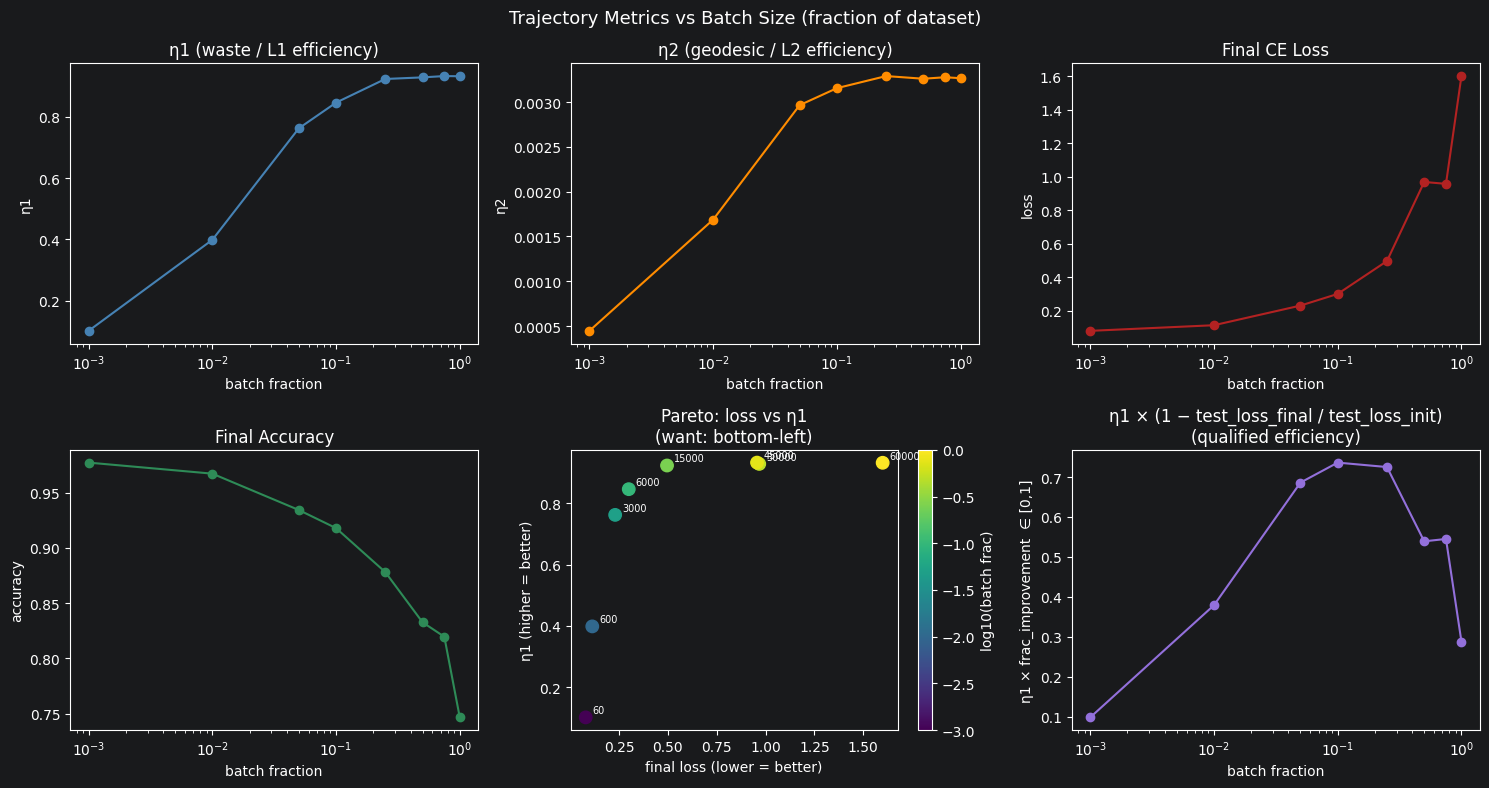

In [73]:
fracs   = [results[bs]['batch_frac'] for bs in batch_sizes]
eta1s   = [results[bs]['final_eta1'] for bs in batch_sizes]
eta2s   = [results[bs]['final_eta2'] for bs in batch_sizes]
losses  = [results[bs]['final_test_loss'] for bs in batch_sizes]
accs    = [results[bs]['final_acc']  for bs in batch_sizes]
eff_ql  = [results[bs]['qualified_efficiency'] for bs in batch_sizes]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Trajectory Metrics vs Batch Size (fraction of dataset)', fontsize=13)

ax = axes[0, 0]
ax.plot(fracs, eta1s, 'o-', color='steelblue')
ax.set_title('η1 (waste / L1 efficiency)')
ax.set_xlabel('batch fraction')
ax.set_ylabel('η1')
ax.set_xscale('log')

ax = axes[0, 1]
ax.plot(fracs, eta2s, 'o-', color='darkorange')
ax.set_title('η2 (geodesic / L2 efficiency)')
ax.set_xlabel('batch fraction')
ax.set_ylabel('η2')
ax.set_xscale('log')

ax = axes[0, 2]
ax.plot(fracs, losses, 'o-', color='firebrick')
ax.set_title('Final CE Loss')
ax.set_xlabel('batch fraction')
ax.set_ylabel('loss')
ax.set_xscale('log')

ax = axes[1, 0]
ax.plot(fracs, accs, 'o-', color='seagreen')
ax.set_title('Final Accuracy')
ax.set_xlabel('batch fraction')
ax.set_ylabel('accuracy')
ax.set_xscale('log')

ax = axes[1, 1]
sc = ax.scatter(losses, eta1s, c=np.log10([f for f in fracs]),
                cmap='viridis', s=80, zorder=3)
for bs, x, y in zip(batch_sizes, losses, eta1s):
    ax.annotate(str(bs), (x, y), textcoords='offset points', xytext=(5, 3), fontsize=7)
plt.colorbar(sc, ax=ax, label='log10(batch frac)')
ax.set_title('Pareto: loss vs η1\n(want: bottom-left)')
ax.set_xlabel('final loss (lower = better)')
ax.set_ylabel('η1 (higher = better)')

ax = axes[1, 2]
ax.plot(fracs, eff_ql, 'o-', color='mediumpurple')
ax.set_title('η1 × (1 − test_loss_final / test_loss_init)\n(qualified efficiency)')
ax.set_xlabel('batch fraction')
ax.set_ylabel('η1 × frac_improvement  ∈ [0,1]')
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('figs/5a_final_metrics_vs_batch_fraction.png', dpi=150, bbox_inches='tight')
plt.show()

## 5b. η1 vs η2 Gap

The shaded area between η1 and η2 captures **directional dispersion**: parameters are each moving with purpose (η1 is high) but not necessarily in the same direction (η2 is lower). A narrow gap means coherent, coordinated movement.

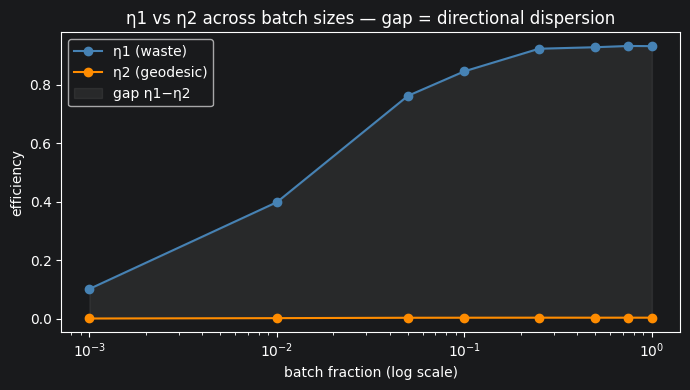

In [74]:
gaps = [e1 - e2 for e1, e2 in zip(eta1s, eta2s)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fracs, eta1s, 'o-', label='η1 (waste)', color='steelblue')
ax.plot(fracs, eta2s, 'o-', label='η2 (geodesic)', color='darkorange')
ax.fill_between(fracs, eta2s, eta1s, alpha=0.15, color='gray', label='gap η1−η2')
ax.set_xscale('log')
ax.set_xlabel('batch fraction (log scale)')
ax.set_ylabel('efficiency')
ax.set_title('η1 vs η2 across batch sizes — gap = directional dispersion')
ax.legend()
plt.tight_layout()
plt.savefig('figs/5b_eta1_eta2_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5c. Per-Parameter η_i Distributions

Network-scalar η1 masks the spread underneath. These histograms show how individual parameter efficiencies are distributed for each batch size — some parameters may move very purposefully while others oscillate.

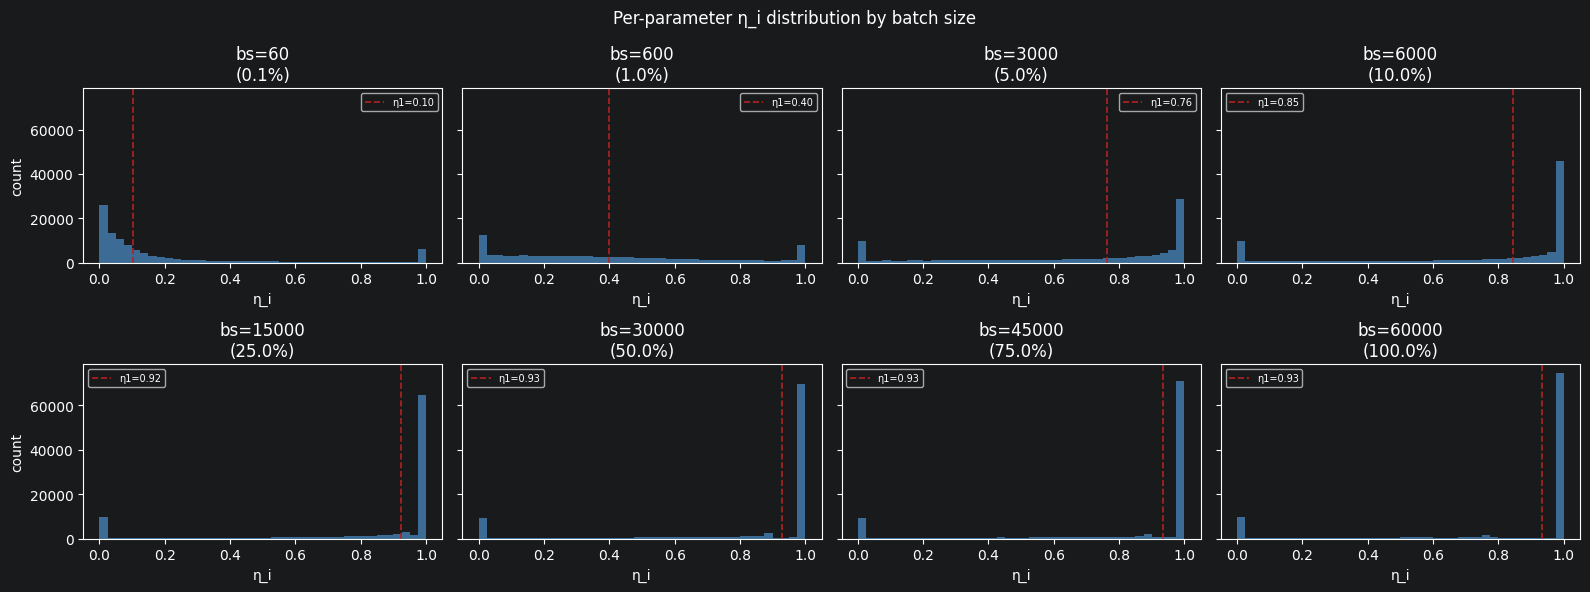

In [75]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=True)
fig.suptitle('Per-parameter η_i distribution by batch size', fontsize=12)

for ax, bs in zip(axes.flat, batch_sizes):
    eta_i = results[bs]['eta_i'].numpy()
    ax.hist(eta_i, bins=40, color='steelblue', alpha=0.8)
    ax.axvline(results[bs]['final_eta1'], color='firebrick', linestyle='--',
               linewidth=1.2, label=f'η1={results[bs]["final_eta1"]:.2f}')
    ax.set_title(f'bs={bs}\n({bs/DATASET_SIZE*100:.1f}%)')
    ax.set_xlabel('η_i')
    ax.legend(fontsize=7)

axes[0, 0].set_ylabel('count')
axes[1, 0].set_ylabel('count')
plt.tight_layout()
plt.savefig('figs/5c_per_param_eta_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5d. Training Curves

Step-level loss and cumulative η1 over training for a representative subset of batch sizes, with training progress normalised to [0, 1] so curves are comparable despite different step counts.

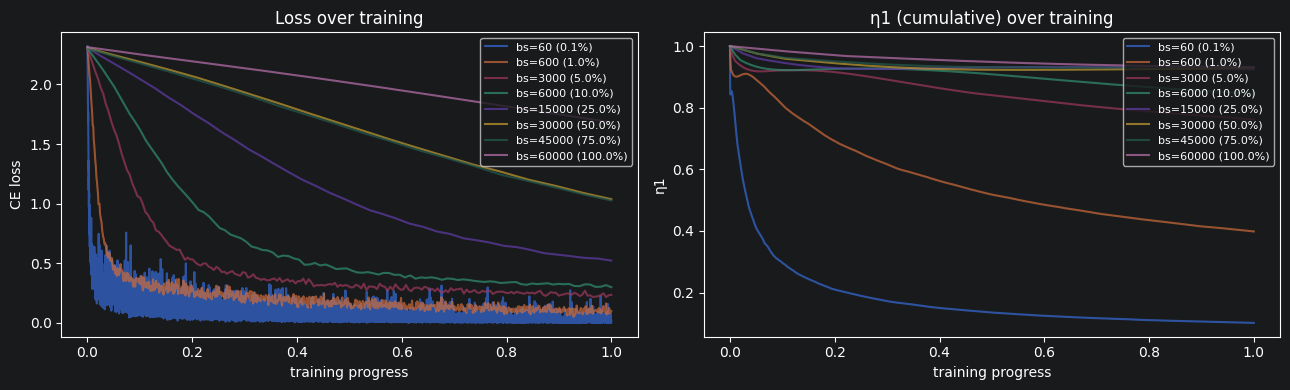

In [76]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for bs in batch_sizes:
    r = results[bs]
    label = f'bs={bs} ({bs/DATASET_SIZE*100:.1f}%)'
    steps = np.linspace(0, 1, len(r['loss_history']))
    ax1.plot(steps, r['loss_history'], alpha=0.7, label=label)
    ax2.plot(steps, r['eta1_history'], alpha=0.7, label=label)

ax1.set_title('Loss over training')
ax1.set_xlabel('training progress')
ax1.set_ylabel('CE loss')
ax1.legend(fontsize=8)

ax2.set_title('η1 (cumulative) over training')
ax2.set_xlabel('training progress')
ax2.set_ylabel('η1')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figs/5d_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5e. TOPSIS Distance to Ideal

A single principled scalar ranking: both axes are normalised to [0, 1] and Euclidean distance to the ideal point (loss = 0, η1 = 1) is computed. Lower distance = closer to optimal.

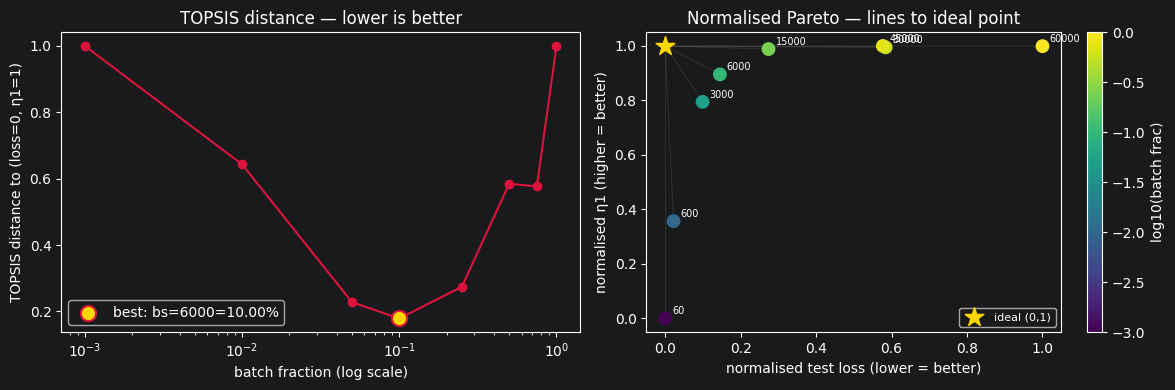


TOPSIS ranking (lower = better):
  #1  bs=  6000 ( 10.0%)  distance=0.1786
  #2  bs=  3000 (  5.0%)  distance=0.2279
  #3  bs= 15000 ( 25.0%)  distance=0.2741
  #4  bs= 45000 ( 75.0%)  distance=0.5770
  #5  bs= 30000 ( 50.0%)  distance=0.5844
  #6  bs=   600 (  1.0%)  distance=0.6432
  #7  bs=    60 (  0.1%)  distance=1.0000
  #8  bs= 60000 (100.0%)  distance=1.0000


In [77]:
fracs  = [results[bs]['batch_frac']      for bs in batch_sizes]
eta1s  = [results[bs]['final_eta1']      for bs in batch_sizes]
losses = [results[bs]['final_test_loss'] for bs in batch_sizes]

loss_arr = np.array(losses)
eta1_arr = np.array(eta1s)

# Normalize to [0, 1]
loss_norm = (loss_arr - loss_arr.min()) / (loss_arr.max() - loss_arr.min() + 1e-12)
eta1_norm = (eta1_arr - eta1_arr.min()) / (eta1_arr.max() - eta1_arr.min() + 1e-12)

# Ideal point: (loss_norm=0, eta1_norm=1)
topsis_dist = np.sqrt(loss_norm**2 + (1 - eta1_norm)**2)

best_idx = np.argmin(topsis_dist)
best_bs  = batch_sizes[best_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(fracs, topsis_dist, 'o-', color='crimson')
ax1.scatter([fracs[best_idx]], [topsis_dist[best_idx]],
            s=120, zorder=5, color='gold', edgecolors='crimson', linewidths=1.5,
            label=f'best: bs={best_bs}={batch_fracs[best_idx]*100.0:.2f}%')
ax1.set_xscale('log')
ax1.set_xlabel('batch fraction (log scale)')
ax1.set_ylabel('TOPSIS distance to (loss=0, η1=1)')
ax1.set_title('TOPSIS distance — lower is better')
ax1.legend()

sc = ax2.scatter(loss_norm, eta1_norm,
                 c=np.log10(fracs), cmap='viridis', s=80, zorder=3)
for bs, x, y in zip(batch_sizes, loss_norm, eta1_norm):
    ax2.annotate(str(bs), (x, y), textcoords='offset points', xytext=(5, 3), fontsize=7)
ax2.scatter([0], [1], marker='*', s=200, color='gold', zorder=5, label='ideal (0,1)')
for x, y, d in zip(loss_norm, eta1_norm, topsis_dist):
    ax2.plot([x, 0], [y, 1], color='gray', alpha=0.2, linewidth=0.8)
plt.colorbar(sc, ax=ax2, label='log10(batch frac)')
ax2.set_xlabel('normalised test loss (lower = better)')
ax2.set_ylabel('normalised η1 (higher = better)')
ax2.set_title('Normalised Pareto — lines to ideal point')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figs/5e_topsis_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTOPSIS ranking (lower = better):')
ranked = sorted(zip(topsis_dist, batch_sizes, fracs), key=lambda x: x[0])
for rank, (dist, bs, frac) in enumerate(ranked, 1):
    print(f'  #{rank}  bs={bs:6d} ({frac*100:5.1f}%)  distance={dist:.4f}')

## 6. Grid Sweep Configuration: Batch Fraction × Learning Rate



In [78]:
GRID_BATCH_FRACS = [0.001, 0.01, 0.05, 0.10, 0.25, 0.50]
GRID_LRS         = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2]
GRID_EPOCHS      = 10

# Derived
GRID_BATCH_SIZES = [max(1, int(f * DATASET_SIZE)) for f in GRID_BATCH_FRACS]

print(f'Grid: {len(GRID_BATCH_SIZES)} batch sizes × {len(GRID_LRS)} LRs'
      f' = {len(GRID_BATCH_SIZES)*len(GRID_LRS)} trials')
print(f'Batch sizes: {GRID_BATCH_SIZES}')
print(f'LRs:         {GRID_LRS}')

Grid: 6 batch sizes × 6 LRs = 36 trials
Batch sizes: [60, 600, 3000, 6000, 15000, 30000]
LRs:         [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03]


## 7. Run the Grid Sweep

Trains one fresh model per (batch size, LR) pair. Results stored in `grid_results[batch_size][lr]`. Re-run to redo with fresh random seeds.

In [79]:
grid_results = {bs: {} for bs in GRID_BATCH_SIZES}
total = len(GRID_BATCH_SIZES) * len(GRID_LRS)
done  = 0

for bs in GRID_BATCH_SIZES:
    for lr in GRID_LRS:
        done += 1
        print(f'[{done}/{total}] bs={bs} lr={lr:.0e} ...', end=' ', flush=True)
        r = run_trial(bs, num_epochs=GRID_EPOCHS, lr=lr, verbose=False)
        grid_results[bs][lr] = r
        print(f'loss={r["final_test_loss"]:.3f} η1={r["final_eta1"]:.3f}'
              f' qual={r["qualified_efficiency"]:.3f}')

print('\nGrid sweep complete.')

[1/36] bs=60 lr=1e-04 ... loss=0.170 η1=0.258 qual=0.239
[2/36] bs=60 lr=3e-04 ... loss=0.091 η1=0.154 qual=0.148
[3/36] bs=60 lr=1e-03 ... loss=0.070 η1=0.103 qual=0.100
[4/36] bs=60 lr=3e-03 ... loss=0.117 η1=0.084 qual=0.080
[5/36] bs=60 lr=1e-02 ... loss=0.210 η1=0.088 qual=0.080
[6/36] bs=60 lr=3e-02 ... loss=0.327 η1=0.104 qual=0.089
[7/36] bs=600 lr=1e-04 ... loss=0.318 η1=0.821 qual=0.707
[8/36] bs=600 lr=3e-04 ... loss=0.204 η1=0.609 qual=0.555
[9/36] bs=600 lr=1e-03 ... loss=0.114 η1=0.401 qual=0.381
[10/36] bs=600 lr=3e-03 ... loss=0.083 η1=0.288 qual=0.278
[11/36] bs=600 lr=1e-02 ... loss=0.097 η1=0.220 qual=0.210
[12/36] bs=600 lr=3e-02 ... loss=0.189 η1=0.223 qual=0.205
[13/36] bs=3000 lr=1e-04 ... loss=0.849 η1=0.942 qual=0.594
[14/36] bs=3000 lr=3e-04 ... loss=0.374 η1=0.896 qual=0.750
[15/36] bs=3000 lr=1e-03 ... loss=0.228 η1=0.766 qual=0.690
[16/36] bs=3000 lr=3e-03 ... loss=0.136 η1=0.613 qual=0.577
[17/36] bs=3000 lr=1e-02 ... loss=0.092 η1=0.506 qual=0.486
[18/36]

## 8a. Grid Heatmaps — 4-Panel

Each panel is a 6 × 6 heatmap over batch fraction (x-axis, small → large) and learning rate (y-axis, high → low). The **TOPSIS panel** (bottom-right, Purples_r) gives the joint optimum at a glance — find the darkest cell.

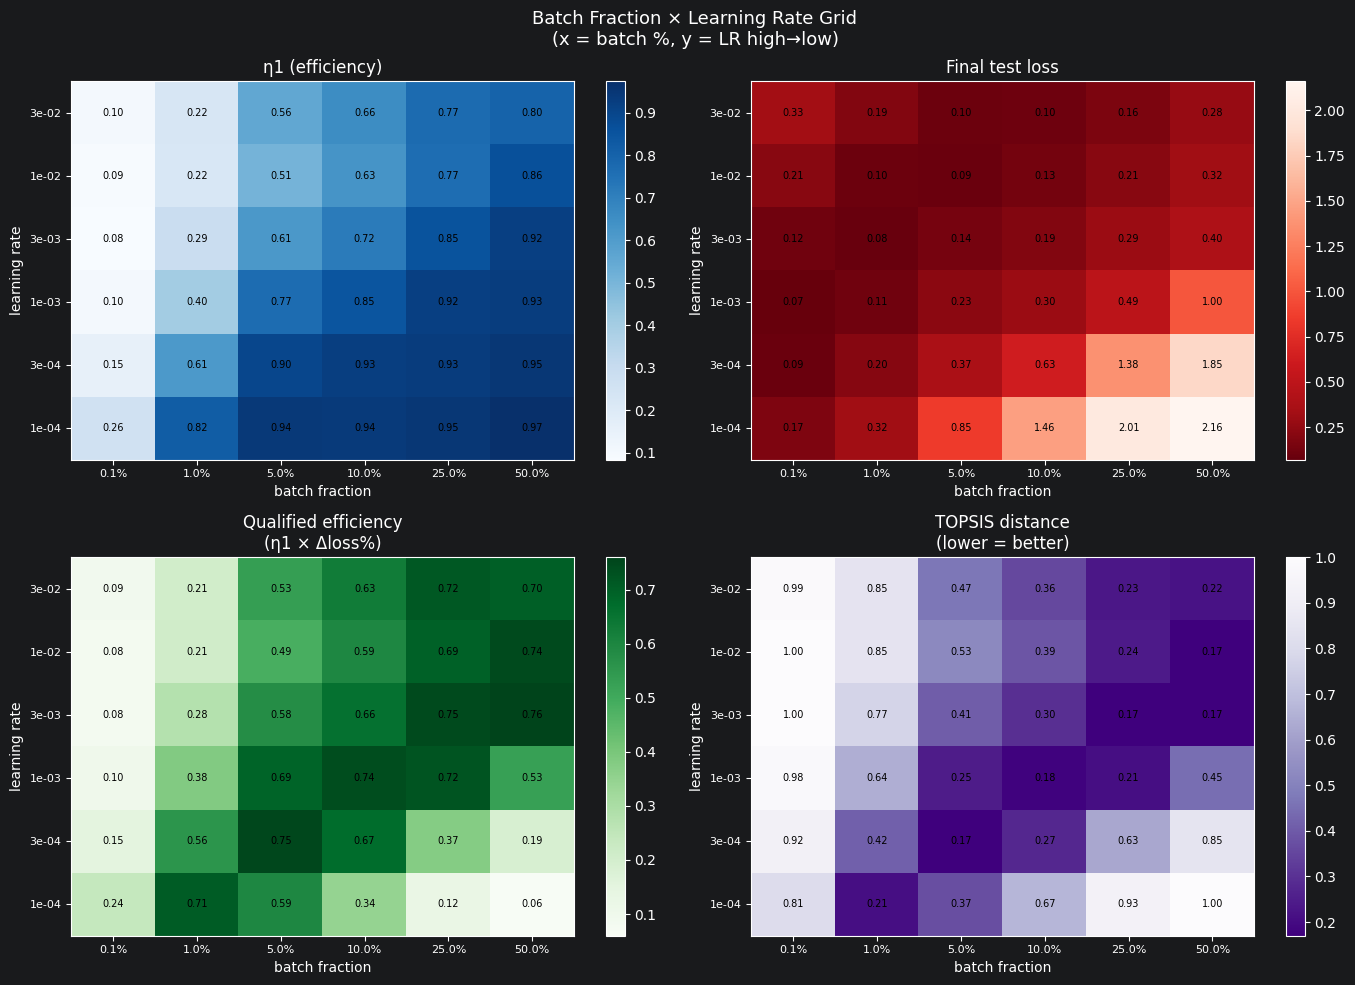

In [80]:
nB = len(GRID_BATCH_SIZES)
nL = len(GRID_LRS)

lrs_plot  = GRID_LRS[::-1]   # high→low for y-axis
bs_plot   = GRID_BATCH_SIZES  # small→large for x-axis

def make_grid(key, transform=None):
    arr = np.zeros((nL, nB))
    for j, bs in enumerate(bs_plot):
        for i, lr in enumerate(lrs_plot):
            val = grid_results[bs][lr][key]
            arr[i, j] = transform(val) if transform else val
    return arr

# TOPSIS distance for each cell
all_losses = np.array([grid_results[bs][lr]['final_test_loss']
                        for bs in GRID_BATCH_SIZES for lr in GRID_LRS])
all_eta1s  = np.array([grid_results[bs][lr]['final_eta1']
                        for bs in GRID_BATCH_SIZES for lr in GRID_LRS])
l_min, l_max = all_losses.min(), all_losses.max()
e_min, e_max = all_eta1s.min(),  all_eta1s.max()

def topsis_cell(bs, lr):
    l = (grid_results[bs][lr]['final_test_loss'] - l_min) / (l_max - l_min + 1e-12)
    e = (grid_results[bs][lr]['final_eta1']       - e_min) / (e_max - e_min + 1e-12)
    return np.sqrt(l**2 + (1 - e)**2)

topsis_grid = np.zeros((nL, nB))
for j, bs in enumerate(bs_plot):
    for i, lr in enumerate(lrs_plot):
        topsis_grid[i, j] = topsis_cell(bs, lr)

grids = {
    'η1 (efficiency)':            (make_grid('final_eta1'),              'Blues',    False),
    'Final test loss':             (make_grid('final_test_loss'),         'Reds_r',   False),
    'Qualified efficiency\n(η1 × Δloss%)': (make_grid('qualified_efficiency'), 'Greens',  False),
    'TOPSIS distance\n(lower = better)':   (topsis_grid,                  'Purples_r', False),
}

x_labels = [f'{f*100:.1f}%' for f in GRID_BATCH_FRACS]
y_labels  = [f'{lr:.0e}' for lr in lrs_plot]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Batch Fraction × Learning Rate Grid\n'
             '(x = batch %, y = LR high→low)', fontsize=13)

for ax, (title, (arr, cmap, _)) in zip(axes.flat, grids.items()):
    im = ax.imshow(arr, cmap=cmap, aspect='auto')
    ax.set_xticks(range(nB)); ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_yticks(range(nL)); ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_xlabel('batch fraction')
    ax.set_ylabel('learning rate')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for i in range(nL):
        for j in range(nB):
            ax.text(j, i, f'{arr[i,j]:.2f}', ha='center', va='center',
                    fontsize=7, color='black')

plt.tight_layout()
plt.savefig('figs/8a_grid_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 8b. Efficiency Ridge & Best Config Summary

For each batch size, the LR that maximises qualified efficiency is identified. The **ridge plot** traces this envelope across batch sizes and reveals how the optimal LR scales with batch size.

      bs    best_lr   qual_eff  test_loss   topsis
      60      1e-04     0.2389     0.1703   0.8058
     600      1e-04     0.7074     0.3179   0.2093
    3000      3e-04     0.7502     0.3744   0.1702
    6000      1e-03     0.7404     0.2956   0.1773
   15000      3e-03     0.7460     0.2918   0.1718
   30000      3e-03     0.7598     0.4029   0.1699


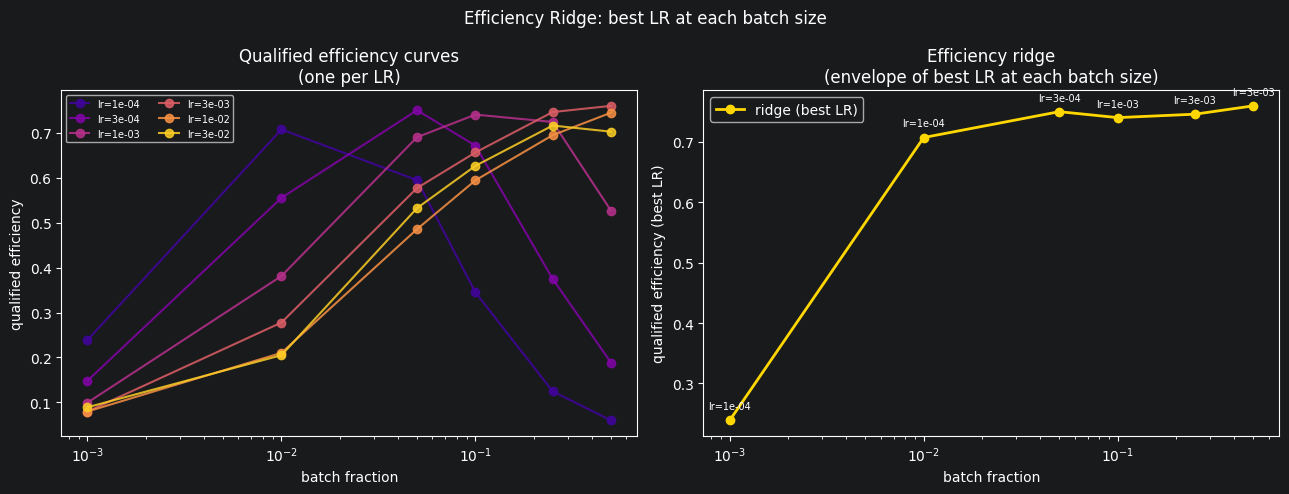


Overall best config: bs=30000 (50.0%), lr=3e-03
  qualified_efficiency = 0.7598
  final test loss      = 0.4029


In [81]:
best_lr_per_bs      = {}
best_qual_per_bs    = {}
best_loss_per_bs    = {}
best_topsis_per_bs  = {}

print(f'{"bs":>8} {"best_lr":>10} {"qual_eff":>10} {"test_loss":>10} {"topsis":>8}')
for bs in GRID_BATCH_SIZES:
    best_lr = min(GRID_LRS, key=lambda lr: -grid_results[bs][lr]['qualified_efficiency'])
    r = grid_results[bs][best_lr]
    best_lr_per_bs[bs]     = best_lr
    best_qual_per_bs[bs]   = r['qualified_efficiency']
    best_loss_per_bs[bs]   = r['final_test_loss']
    best_topsis_per_bs[bs] = topsis_cell(bs, best_lr)
    print(f'{bs:>8d} {best_lr:>10.0e} {r["qualified_efficiency"]:>10.4f}'
          f' {r["final_test_loss"]:>10.4f} {best_topsis_per_bs[bs]:>8.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Efficiency Ridge: best LR at each batch size', fontsize=12)

fracs_g = [bs / DATASET_SIZE for bs in GRID_BATCH_SIZES]

cmap_lines = plt.cm.plasma(np.linspace(0.1, 0.9, len(GRID_LRS)))
for lr, color in zip(GRID_LRS, cmap_lines):
    quals = [grid_results[bs][lr]['qualified_efficiency'] for bs in GRID_BATCH_SIZES]
    ax1.plot(fracs_g, quals, 'o-', color=color, label=f'lr={lr:.0e}', alpha=0.85)
ax1.set_xscale('log')
ax1.set_xlabel('batch fraction')
ax1.set_ylabel('qualified efficiency')
ax1.set_title('Qualified efficiency curves\n(one per LR)')
ax1.legend(fontsize=7, ncol=2)

best_quals = [best_qual_per_bs[bs] for bs in GRID_BATCH_SIZES]
best_lrs   = [best_lr_per_bs[bs]   for bs in GRID_BATCH_SIZES]
ax2.plot(fracs_g, best_quals, 'o-', color='gold', linewidth=2, label='ridge (best LR)')
for f, q, lr in zip(fracs_g, best_quals, best_lrs):
    ax2.annotate(f'lr={lr:.0e}', (f, q), textcoords='offset points',
                 xytext=(0, 8), fontsize=7, ha='center')
ax2.set_xscale('log')
ax2.set_xlabel('batch fraction')
ax2.set_ylabel('qualified efficiency (best LR)')
ax2.set_title('Efficiency ridge\n(envelope of best LR at each batch size)')
ax2.legend()

plt.tight_layout()
plt.savefig('figs/8b_efficiency_ridge.png', dpi=150, bbox_inches='tight')
plt.show()

overall_best_bs = max(GRID_BATCH_SIZES, key=lambda bs: best_qual_per_bs[bs])
overall_best_lr = best_lr_per_bs[overall_best_bs]
print(f'\nOverall best config: bs={overall_best_bs}'
      f' ({overall_best_bs/DATASET_SIZE*100:.1f}%), lr={overall_best_lr:.0e}')
print(f'  qualified_efficiency = {best_qual_per_bs[overall_best_bs]:.4f}')
print(f'  final test loss      = {best_loss_per_bs[overall_best_bs]:.4f}')

## 9. Observations & Next Directions

### What the 1-D sweep shows
- **η1 rises monotonically with batch size** — expected. Larger batches = lower-variance gradient = fewer reversals per parameter.
- **Loss is not monotone** — very large batches degrade generalisation (sharp minima, fewer update steps).
- **Qualified efficiency peaks at an intermediate batch size** — the sweet spot where movement is directed *and* the model actually learns.
- **The TOPSIS distance** (Cell 5e) gives a single principled scalar ranking.

### What the grid sweep shows
- **The qualified efficiency ridge** (Cell 8b) traces the optimal LR for each batch size.
- **The efficiency heatmap reveals the diagonal co-scaling rule** that the loss heatmap obscures: efficiency is preserved when LR and batch size are increased together — but not necessarily at the same rate.
- **LR and batch size interact non-separably.** The heatmap shows a ridge rather than a corner optimum.

### What the epoch evolution shows (Cells 9b / 10)
- The landscape is not static — the optimal (batch_size, LR) pair shifts over epochs.
- η1 decay is the natural signal for when a regime is exhausted, motivating the scheduler in Cell 10.
- The goal of the scheduler is maximum **cumulative** qualified efficiency over the entire run, not just the final value.

### Known limitation: lambda_fn proxy
The current `lambda_fn` uses `grad²` as a proxy for the output Jacobian. The true Metric II requires `p` separate backward passes. Sufficient for comparing configurations; swap in the true Jacobian for the grokking transformer experiments.

### Next sweeps

| Axis | Where to change | Question |
| --- | --- | --- |
| Architecture depth | `make_model()` in Cell 2 | Does deeper = more churn at small batch? |
| Optimizer | Add `optimizer` param to `run_trial` | What does Adam's adaptive scaling do to η1 vs SGD? |
| Dataset fraction | Subsample `_mnist_train` in Cell 1 | Less data → lower efficiency at any batch size? |
| Task (grokking) | Swap MNIST for modular arithmetic loader | Does η1 spike at the grokking transition? |
| Batch+LR schedule | Cell 10 | Does η1-triggered co-scaling beat any fixed schedule? |
| Co-scaling rate | Extend Cell 10 | What is the optimal ΔLR / Δbatch_size ratio along the ridge? |
| η1 dynamics model | Fit surface from Cell 9b data | Can we derive the optimal schedule analytically from ∂η1/∂bs and ∂η1/∂lr? |


## 9b. Per-Epoch Efficiency Landscape

How does the qualified efficiency heatmap evolve over training? Each panel below is a snapshot of the full 6×6 grid after that epoch, with a **shared colour scale** so brightness is directly comparable.

The key question: is the optimal (batch_size, LR) configuration stable from epoch 1, or does it migrate as training progresses? This informs how the scheduler in Cell 10 should be designed.

> **Requires:** re-run cells 4 and 7 first to populate `epoch_snapshots` in `grid_results`.


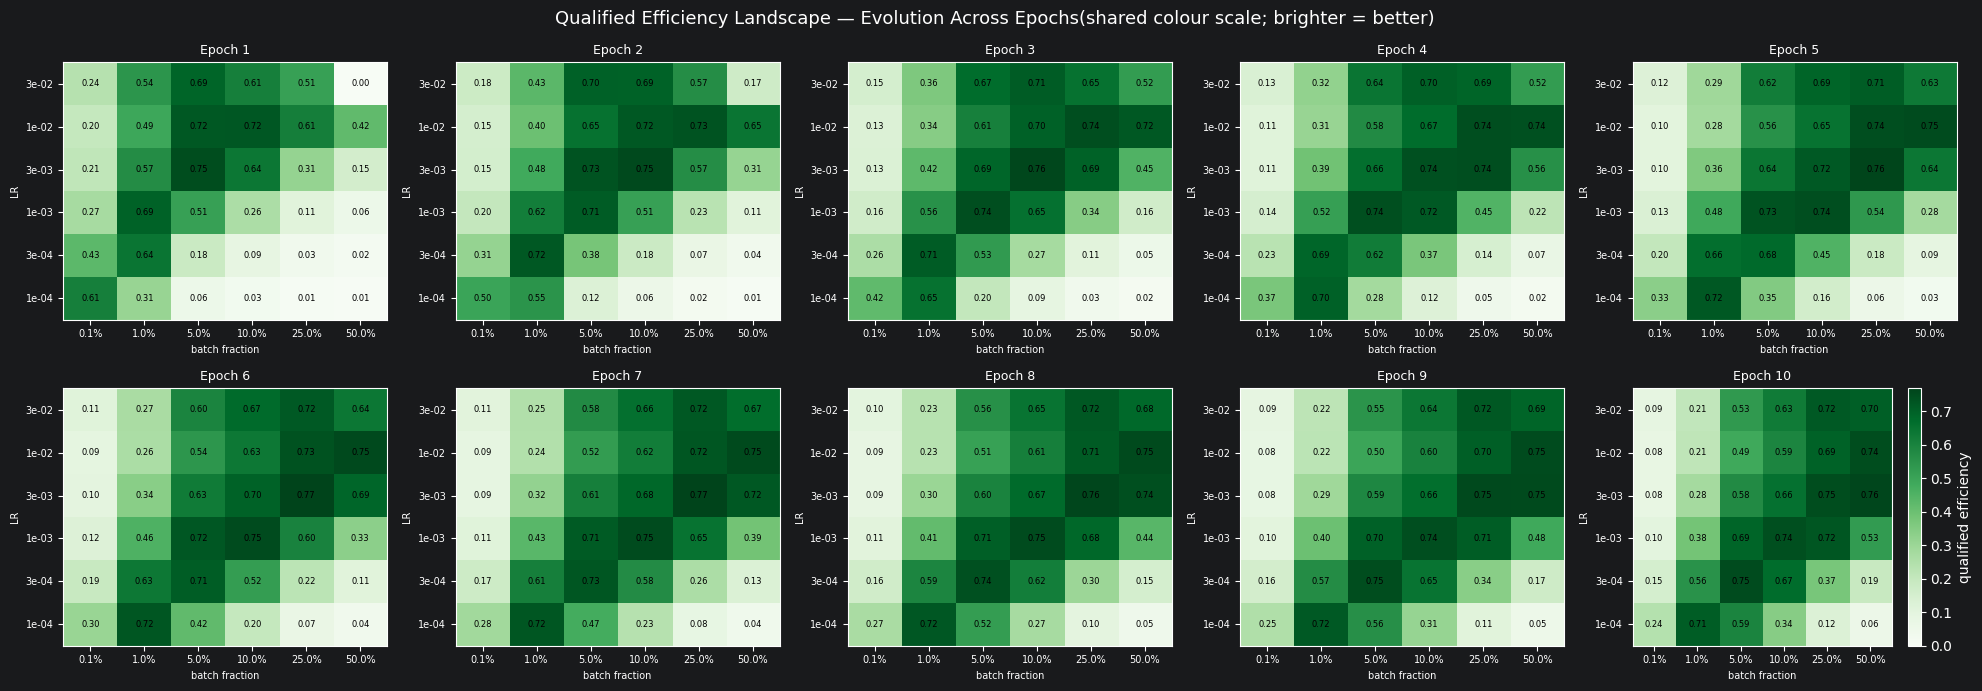

In [82]:
_sample = grid_results[GRID_BATCH_SIZES[0]][GRID_LRS[0]]
assert 'epoch_snapshots' in _sample, (
    "Re-run cells 4 and 7 to populate epoch_snapshots in grid_results."
)

_nE = GRID_EPOCHS
_nB = len(GRID_BATCH_SIZES)
_nL = len(GRID_LRS)
_lrs_plot = GRID_LRS[::-1]
_bs_plot  = GRID_BATCH_SIZES
_x_labels = [f'{f*100:.1f}%' for f in GRID_BATCH_FRACS]
_y_labels  = [f'{lr:.0e}' for lr in _lrs_plot]

qual_over_epochs = np.zeros((_nE, _nL, _nB))
for e in range(_nE):
    for j, bs in enumerate(_bs_plot):
        for i, lr in enumerate(_lrs_plot):
            qual_over_epochs[e, i, j] = (
                grid_results[bs][lr]['epoch_snapshots'][e]['qualified_efficiency']
            )

_vmin = qual_over_epochs.min()
_vmax = qual_over_epochs.max()
_ncols = 5
_nrows = (_nE + _ncols - 1) // _ncols

fig, axes = plt.subplots(_nrows, _ncols, figsize=(4 * _ncols, 3.5 * _nrows))
if _nrows == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('Qualified Efficiency Landscape — Evolution Across Epochs'
             '(shared colour scale; brighter = better)', fontsize=13)

for e in range(_nE):
    row, col = divmod(e, _ncols)
    ax = axes[row, col]
    im = ax.imshow(qual_over_epochs[e], cmap='Greens', aspect='auto',
                   vmin=_vmin, vmax=_vmax)
    ax.set_xticks(range(_nB)); ax.set_xticklabels(_x_labels, fontsize=7)
    ax.set_yticks(range(_nL)); ax.set_yticklabels(_y_labels, fontsize=7)
    ax.set_xlabel('batch fraction', fontsize=7)
    ax.set_ylabel('LR', fontsize=7)
    ax.set_title(f'Epoch {e + 1}', fontsize=9)
    for ii in range(_nL):
        for jj in range(_nB):
            ax.text(jj, ii, f'{qual_over_epochs[e, ii, jj]:.2f}',
                    ha='center', va='center', fontsize=6, color='black')

for e in range(_nE, _nrows * _ncols):
    row, col = divmod(e, _ncols)
    axes[row, col].set_visible(False)

plt.colorbar(im, ax=axes.flat[_nE - 1], label='qualified efficiency')
plt.tight_layout()
plt.savefig('figs/9b_epoch_efficiency_evolution.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. η1-Triggered Co-Scaling Scheduler

### The idea

η1 decays over training as the model extracts information from the current (batch_size, LR) regime. When η1 **stops decaying** — the per-epoch drop Δη1 → 0 — the regime is exhausted. That is the natural trigger to advance to the next configuration along the efficiency ridge.

The analogy to options **delta** is precise: η1 measures how sensitively the parameter trajectory responds to current training conditions. When delta flattens, the sensitivity has been consumed.

### The protocol

1. Define a **schedule path**: a discrete sequence of (batch_size, LR) pairs tracing the grid diagonal. Each step has its own scaling ratio — LR and batch size do *not* necessarily co-scale at the same rate.
2. Start at step 0: smallest batch, lowest LR.
3. After each epoch: if Δη1 < `ETA1_PLATEAU_THRESHOLD`, advance to the next step.
4. The goal is maximum **cumulative** qualified efficiency over the whole run, not just the final value.

### Why the grid diagonal?

Rather than applying a blind constant scale factor, we step through the exact (batch_size, LR) pairs from the 2-D grid sweep. This means:
- The schedule path is empirically grounded in the known efficiency landscape
- Each step has a specific, grid-measured qualified efficiency score
- The red box in the heatmaps below shows exactly which cell is active each epoch

### The open question

The grid diagonal is one path through the landscape, but is it the *optimal* path? The epoch-by-epoch heatmaps reveal whether the best cell migrates in a way that suggests a different trajectory. Eventually, with enough data, one could fit η1(batch_size, lr, epoch) and compute ∂η1/∂bs and ∂η1/∂lr analytically — continuous gradient ascent rather than a discrete threshold rule.

### Config (edit here)


In [83]:
# ── Scheduler config — edit these ────────────────────────────────────────
# Default path: diagonal of the grid
SCHEDULE_PATH = list(zip(GRID_BATCH_SIZES, GRID_LRS))

ETA1_PLATEAU_THRESHOLD = 0.02   # Δη1/epoch below this → advance to next step

print('Schedule path (stepping along grid diagonal):')
print(f'  {"step":>5} {"batch_size":>12} {"batch_frac":>12} {"lr":>10} {"bs_ratio":>10} {"lr_ratio":>10}')
prev_bs, prev_lr = None, None
for k, (bs, lr) in enumerate(SCHEDULE_PATH):
    bs_ratio = f'{bs/prev_bs:.1f}x' if prev_bs else '-'
    lr_ratio = f'{lr/prev_lr:.1f}x' if prev_lr else '-'
    print(f'  {k:>5d} {bs:>12d} {bs/DATASET_SIZE*100:>11.1f}% {lr:>10.0e} '
          f'{bs_ratio:>10} {lr_ratio:>10}')
    prev_bs, prev_lr = bs, lr


def run_eta1_scheduled_trial(
    schedule_path=None,
    num_epochs=10,
    eta1_plateau_threshold=ETA1_PLATEAU_THRESHOLD,
    verbose=True,
) -> dict:
    """
    Train with η1-triggered co-scaling along the schedule path.
    Advances to the next (batch_size, LR) step when the per-epoch
    η1 decay falls below eta1_plateau_threshold.
    """
    if schedule_path is None:
        schedule_path = SCHEDULE_PATH

    step_idx = 0
    batch_size, lr = schedule_path[step_idx]

    model = make_model()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    _, init_test_loss = evaluate_test(model)

    G = {name: torch.zeros_like(p.data) for name, p in model.named_parameters()}
    D = {name: torch.zeros_like(p.data) for name, p in model.named_parameters()}

    schedule_log = []
    loss_history, eta1_history = [], []
    prev_eta1 = 1.0

    model.train()
    for epoch in range(num_epochs):
        loader = make_loader(batch_size)
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            prev = snapshot_params(model)
            output = model(data)
            loss = criterion(output, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            accumulate_deltas(model, prev, G, D)
            m = compute_network_efficiencies(G, D)
            loss_history.append(loss.item())
            eta1_history.append(m['eta1'])

        # End-of-epoch: snapshot + plateau check
        snap_m = compute_network_efficiencies(G, D)
        _, snap_test_loss = evaluate_test(model)
        snap_frac = max(1.0 - snap_test_loss / max(init_test_loss, 1e-12), 0.0)
        current_eta1 = snap_m['eta1']
        delta_eta1 = prev_eta1 - current_eta1

        schedule_log.append({
            'epoch':                epoch,
            'step_idx':             step_idx,
            'batch_size':           batch_size,
            'lr':                   lr,
            'eta1':                 current_eta1,
            'delta_eta1':           delta_eta1,
            'test_loss':            snap_test_loss,
            'qualified_efficiency': snap_m['eta1'] * snap_frac,
        })

        if verbose:
            print(f'  Epoch {epoch+1:3d}: bs={batch_size:6d} lr={lr:.0e} '
                  f'η1={current_eta1:.4f} Δη1={delta_eta1:+.4f} '
                  f'loss={snap_test_loss:.4f} qual={snap_m["eta1"]*snap_frac:.4f}')

        if delta_eta1 < eta1_plateau_threshold and step_idx < len(schedule_path) - 1:
            step_idx += 1
            batch_size, lr = schedule_path[step_idx]
            for pg in optimizer.param_groups:
                pg['lr'] = lr
            if verbose:
                print(f'           → Plateau! Step → {step_idx}: '
                      f'bs={batch_size}, lr={lr:.0e}')

        prev_eta1 = current_eta1

    final_m = compute_network_efficiencies(G, D)
    final_acc, final_test_loss = evaluate_test(model)
    frac_imp = max(1.0 - final_test_loss / max(init_test_loss, 1e-12), 0.0)

    return dict(
        schedule_log=schedule_log,
        loss_history=loss_history,
        eta1_history=eta1_history,
        final_eta1=final_m['eta1'],
        final_test_loss=final_test_loss,
        final_acc=final_acc,
        frac_improvement=frac_imp,
        qualified_efficiency=final_m['eta1'] * frac_imp,
    )


Schedule path (stepping along grid diagonal):
   step   batch_size   batch_frac         lr   bs_ratio   lr_ratio
      0           60         0.1%      1e-04          -          -
      1          600         1.0%      3e-04      10.0x       3.0x
      2         3000         5.0%      1e-03       5.0x       3.3x
      3         6000        10.0%      3e-03       2.0x       3.0x
      4        15000        25.0%      1e-02       2.5x       3.3x
      5        30000        50.0%      3e-02       2.0x       3.0x


=== Running η1-triggered scheduled trial ===
  Epoch   1: bs=    60 lr=1e-04 η1=0.7352 Δη1=+0.2648 loss=0.4123 qual=0.6038
  Epoch   2: bs=    60 lr=1e-04 η1=0.5764 Δη1=+0.1587 loss=0.3168 qual=0.4973
  Epoch   3: bs=    60 lr=1e-04 η1=0.4787 Δη1=+0.0978 loss=0.2830 qual=0.4200
  Epoch   4: bs=    60 lr=1e-04 η1=0.4139 Δη1=+0.0648 loss=0.2599 qual=0.3673
  Epoch   5: bs=    60 lr=1e-04 η1=0.3675 Δη1=+0.0464 loss=0.2423 qual=0.3289
  Epoch   6: bs=    60 lr=1e-04 η1=0.3337 Δη1=+0.0338 loss=0.2259 qual=0.3010
  Epoch   7: bs=    60 lr=1e-04 η1=0.3080 Δη1=+0.0257 loss=0.2126 qual=0.2796
  Epoch   8: bs=    60 lr=1e-04 η1=0.2870 Δη1=+0.0210 loss=0.2003 qual=0.2621
  Epoch   9: bs=    60 lr=1e-04 η1=0.2700 Δη1=+0.0170 loss=0.1883 qual=0.2480
           → Plateau! Step → 1: bs=600, lr=3e-04
  Epoch  10: bs=   600 lr=3e-04 η1=0.2698 Δη1=+0.0002 loss=0.1835 qual=0.2484
           → Plateau! Step → 2: bs=3000, lr=1e-03


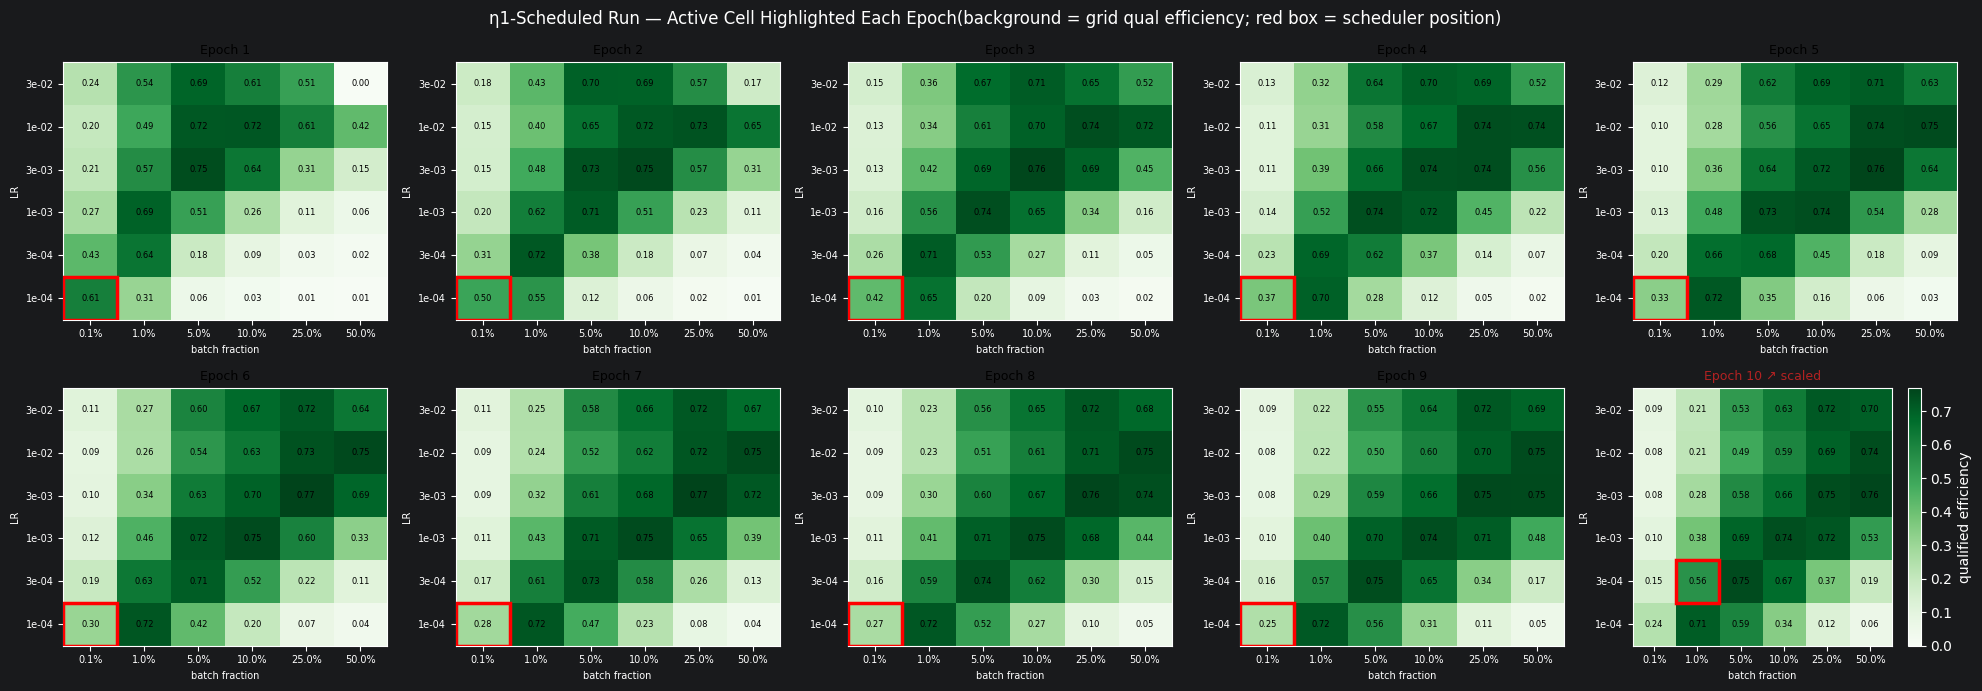

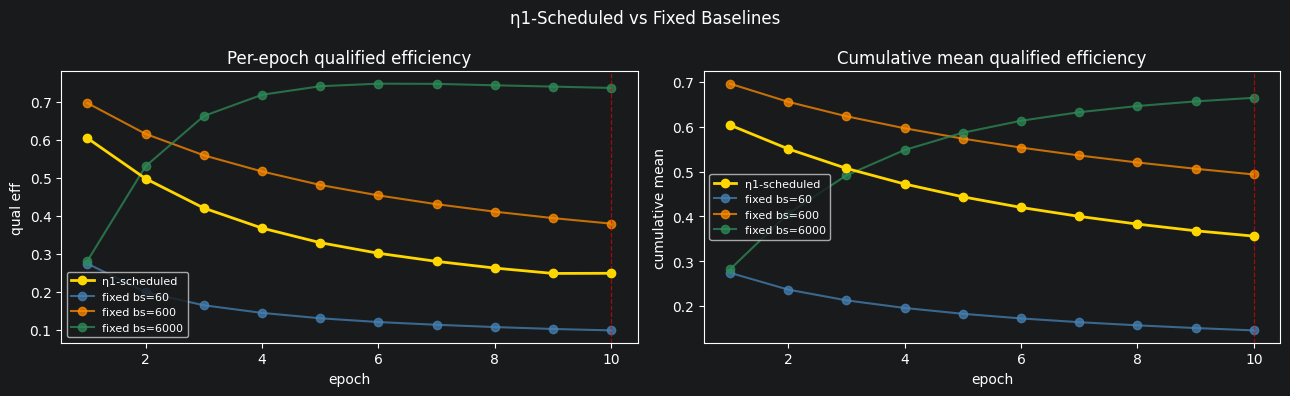


                      config   qual_eff   cum_qual  test_loss      acc       η1
                η1-scheduled     0.2484     0.3556     0.1835   0.9480   0.2698
        fixed bs=60 lr=1e-03     0.0981     0.1450     0.0789   0.9772   0.1016
       fixed bs=600 lr=1e-03     0.3790     0.4934     0.1125   0.9672   0.3984
      fixed bs=6000 lr=1e-03     0.7361     0.6646     0.2995   0.9179   0.8461


In [84]:
print('=== Running η1-triggered scheduled trial ===')
sched_result = run_eta1_scheduled_trial(
    schedule_path=SCHEDULE_PATH,
    num_epochs=GRID_EPOCHS,
    eta1_plateau_threshold=ETA1_PLATEAU_THRESHOLD,
    verbose=True,
)

# ── Per-epoch heatmaps with red box on active cell ──────────────────
_nE = GRID_EPOCHS
_nB = len(GRID_BATCH_SIZES)
_nL = len(GRID_LRS)
_lrs_plot = GRID_LRS[::-1]
_bs_plot  = GRID_BATCH_SIZES
_x_labels = [f'{f*100:.1f}%' for f in GRID_BATCH_FRACS]
_y_labels  = [f'{lr:.0e}' for lr in _lrs_plot]

# Recompute if qual_over_epochs not in scope
try:
    _ = qual_over_epochs
except NameError:
    assert 'epoch_snapshots' in grid_results[GRID_BATCH_SIZES[0]][GRID_LRS[0]], (
        "Re-run cells 4, 7, and 9b before this cell."
    )
    qual_over_epochs = np.zeros((_nE, _nL, _nB))
    for e in range(_nE):
        for j, bs in enumerate(_bs_plot):
            for i, lr in enumerate(_lrs_plot):
                qual_over_epochs[e, i, j] = (
                    grid_results[bs][lr]['epoch_snapshots'][e]['qualified_efficiency']
                )

# Snap (bs, lr) to nearest grid cell for robust red-box lookup
def _nearest_cell(bs, lr):
    j = min(range(_nB), key=lambda x: abs(_bs_plot[x] - bs))
    i = min(range(_nL), key=lambda x: abs(_lrs_plot[x] - lr))
    return j, i

_vmin = qual_over_epochs.min()
_vmax = qual_over_epochs.max()
_ncols = 5
_nrows = (_nE + _ncols - 1) // _ncols

from matplotlib.patches import Rectangle

fig, axes = plt.subplots(_nrows, _ncols, figsize=(4 * _ncols, 3.5 * _nrows))
if _nrows == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('η1-Scheduled Run — Active Cell Highlighted Each Epoch'
             '(background = grid qual efficiency; red box = scheduler position)',
             fontsize=12)

for e, log_entry in enumerate(sched_result['schedule_log']):
    row, col = divmod(e, _ncols)
    ax = axes[row, col]
    im = ax.imshow(qual_over_epochs[e], cmap='Greens', aspect='auto',
                   vmin=_vmin, vmax=_vmax)
    ax.set_xticks(range(_nB)); ax.set_xticklabels(_x_labels, fontsize=7)
    ax.set_yticks(range(_nL)); ax.set_yticklabels(_y_labels, fontsize=7)
    ax.set_xlabel('batch fraction', fontsize=7)
    ax.set_ylabel('LR', fontsize=7)

    for ii in range(_nL):
        for jj in range(_nB):
            ax.text(jj, ii, f'{qual_over_epochs[e, ii, jj]:.2f}',
                    ha='center', va='center', fontsize=6, color='black')

    _j, _i = _nearest_cell(log_entry['batch_size'], log_entry['lr'])
    ax.add_patch(Rectangle((_j - 0.5, _i - 0.5), 1, 1,
                            linewidth=2.5, edgecolor='red',
                            facecolor='none', zorder=5))

    advanced = (e > 0 and
                sched_result['schedule_log'][e]['step_idx'] !=
                sched_result['schedule_log'][e - 1]['step_idx'])
    ax.set_title(f'Epoch {e + 1}'  + (' ↗ scaled' if advanced else ''),
                 fontsize=9, color=('firebrick' if advanced else 'black'))

for e in range(_nE, _nrows * _ncols):
    row, col = divmod(e, _ncols)
    axes[row, col].set_visible(False)

plt.colorbar(im, ax=axes.flat[_nE - 1], label='qualified efficiency')
plt.tight_layout()
plt.savefig('figs/10_scheduled_epoch_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Cumulative qualified efficiency over epochs ────────────────────
# For each run, extract per-epoch qual eff; compute running mean.
# Fixed baselines require re-run cells 4+7 for epoch_snapshots.
_epochs = list(range(1, GRID_EPOCHS + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('η1-Scheduled vs Fixed Baselines', fontsize=12)

# Scheduler per-epoch qual eff
_sched_qe = [e['qualified_efficiency'] for e in sched_result['schedule_log']]
_sched_cum = np.cumsum(_sched_qe) / np.arange(1, len(_sched_qe) + 1)

ax1.plot(_epochs, _sched_qe, 'o-', color='gold', lw=2, label='η1-scheduled', zorder=5)
ax2.plot(_epochs, _sched_cum, 'o-', color='gold', lw=2, label='η1-scheduled', zorder=5)

_bs_baselines = [60, 600, 6000]
_colors = ['steelblue', 'darkorange', 'seagreen']
for bs, color in zip(_bs_baselines, _colors):
    r = results[bs]
    if 'epoch_snapshots' in r:
        _qe = [s['qualified_efficiency'] for s in r['epoch_snapshots']]
        _cum = np.cumsum(_qe) / np.arange(1, len(_qe) + 1)
        ax1.plot(_epochs, _qe, 'o-', color=color, alpha=0.75, label=f'fixed bs={bs}')
        ax2.plot(_epochs, _cum, 'o-', color=color, alpha=0.75, label=f'fixed bs={bs}')
    else:
        print(f'No epoch_snapshots for bs={bs} — re-run cells 4+7 for per-epoch curves')

# Mark scale events with vertical lines
_log = sched_result['schedule_log']
for k in range(1, len(_log)):
    if _log[k]['step_idx'] != _log[k - 1]['step_idx']:
        ax1.axvline(k + 1, color='red', lw=0.9, linestyle='--', alpha=0.6)
        ax2.axvline(k + 1, color='red', lw=0.9, linestyle='--', alpha=0.6)

ax1.set_title('Per-epoch qualified efficiency')
ax1.set_xlabel('epoch'); ax1.set_ylabel('qual eff'); ax1.legend(fontsize=8)
ax2.set_title('Cumulative mean qualified efficiency')
ax2.set_xlabel('epoch'); ax2.set_ylabel('cumulative mean'); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figs/10_scheduled_vs_baselines.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final comparison table ──────────────────────────────────────────
print(f'\n{"config":>28} {"qual_eff":>10} {"cum_qual":>10} '
      f'{"test_loss":>10} {"acc":>8} {"η1":>8}')

def _fmt(label, r, cum_qe=None):
    cq = f'{cum_qe:.4f}' if cum_qe is not None else '     n/a'
    print(f'{label:>28} {r["qualified_efficiency"]:>10.4f} {cq:>10} '
          f'{r["final_test_loss"]:>10.4f} {r["final_acc"]:>8.4f} '
          f'{r["final_eta1"]:>8.4f}')

_fmt('η1-scheduled', sched_result, float(np.mean(_sched_qe)))
for bs, color in zip(_bs_baselines, _colors):
    r = results[bs]
    cum = (float(np.mean([s['qualified_efficiency'] for s in r['epoch_snapshots']]))
           if 'epoch_snapshots' in r else None)
    _fmt(f'fixed bs={bs} lr={SWEEP_LR:.0e}', r, cum)
